# Comprensione del dataset
Notebook di comprensione del dataset Paderborn: ogni sezione risponde a una domanda. La logica sta nei moduli in `src/`; qui orchestriamo e documentiamo.

## Il dataset
- **Chi lo ha creato:** Chair of Design and Drive Technology, Paderborn University (Lessmeier et al., 2016), KAT Bearing Data Center.
- **A cosa serve:** benchmark per la diagnosi di guasti ai cuscinetti di motori a induzione.
- **Come e' organizzato:** un archivio `.rar` per cuscinetto; dentro, le registrazioni `.mat` e i PDF descrittivi.
- **Quali classi contiene:** cuscinetti sani (`K`), guasto anello esterno (`KA`), interno (`KI`), combinato (`KB`).
- **Come sono nominati i file:** `Nxx_Mxx_Fxx_CODICE_i.mat`, cioe' `regime_cuscinetto_ripetizione`.

## Setup

In [1]:
!apt-get -qq install -y unrar
!pip -q install scipy pandas pymupdf matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 85.6 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path

# rende importabili i moduli del progetto in Colab
if not Path('utils').exists():
    !git clone -q https://github.com/matpaol/bearings_detection.git
    %cd bearings_detection

from utils import config, repository, dataset, plots

/content/bearings_detection


## Come e' organizzato il repository remoto?
Non ci interessa il server in se', ma la struttura del dataset: quali cuscinetti esistono.

In [3]:
codes = repository.list_available_bearings(config.BASE_URL)
print(len(codes), 'cuscinetti')
dataset.census(codes)

32 cuscinetti


,location,nature,bearings
0,combined,real,3
1,inner,artificial,5
2,inner,real,6
3,normal,healthy,6
4,outer,artificial,7
5,outer,real,5


## Anatomia di un bearing
Cosa contiene un archivio, quanti file, e perche'. Scarichiamo un cuscinetto sano di riferimento.

In [4]:
archive = repository.download_bearing('K001', config.DATA_DIR, config.BASE_URL)
folder = repository.extract_bearing(archive, config.DATA_DIR)

files = sorted(p.name for p in folder.rglob('*') if p.is_file())
from collections import Counter
suffixes = Counter(Path(f).suffix for f in files)
print('file totali:', len(files))
print('per estensione:', dict(suffixes))

file totali: 82
per estensione: {'.pdf': 2, '.mat': 80}


Ci sono **80 `.mat`** = 4 regimi di carico x 20 ripetizioni, e **2 PDF**: il *profilo di danno* del cuscinetto (geometria) e il *measuring log* (setup e strumentazione).

## Come sono strutturati internamente i segnali?
Un `.mat` contiene una struct con i campi `Info / X / Y / Description`. In `Y` stanno i 7 segnali, ciascuno con nome, dati e metadati:

```
MAT -> struct -> Y (7 segnali) -> metadati -> sampling frequency
```

In [5]:
recording = sorted(folder.rglob('N15_M07_F10_K001_*.mat'))[0]
dataset.signal_summary(recording)

,signal,samples,sampling_hz
0,force,16001,4000
1,phase_current_1,256001,64000
2,phase_current_2,256001,64000
3,speed,16001,4000
4,temp_2_bearing_module,5,1
5,torque,16001,4000
6,vibration_1,256001,64000


## Qual e' l'unita' fondamentale del dataset?
La gerarchia reale, che guidera' il builder del notebook 02:

```
Bearing (K001)
  └─ Condition / regime (N09_M07_F10)      4 regimi
       └─ Measurement (_1 ... _20)          20 ripetizioni = un file .mat
            └─ Signals (7 canali)            corrente, vibrazione, speed, ...
```

L'unita' su disco e' quindi la **measurement** (un `.mat`), che contiene tutti i canali.

## Che aspetto hanno i segnali?
Visualizziamo corrente, vibrazione e velocita' della stessa registrazione. Useremo poi solo la corrente, ma qui documentiamo tutto.

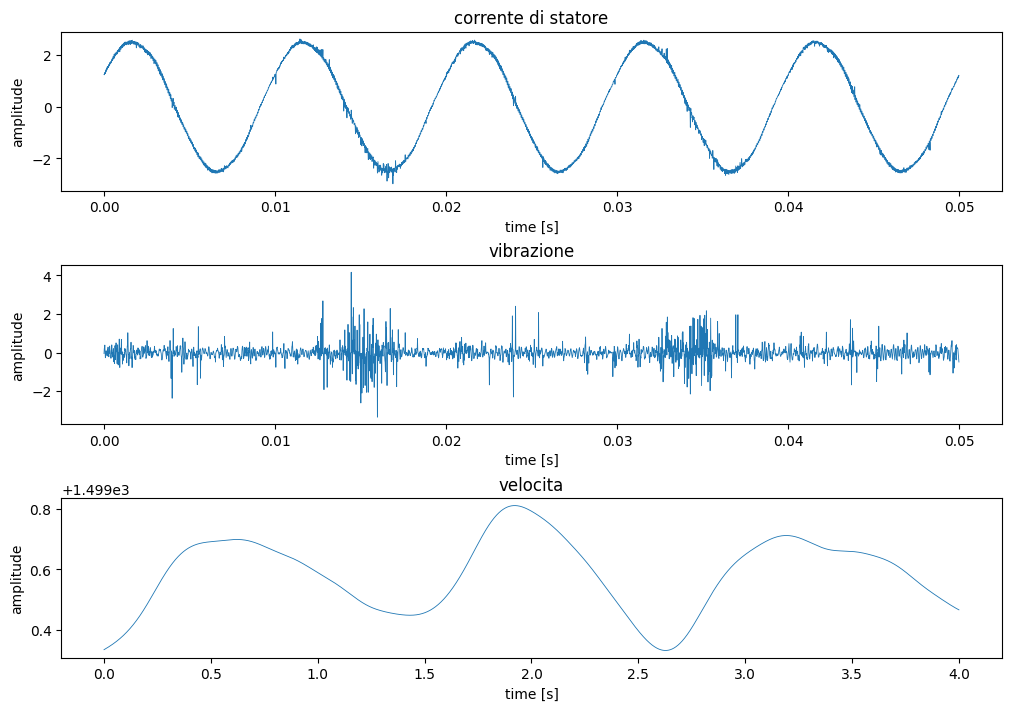

In [6]:
import matplotlib.pyplot as plt

current = dataset.load_signal(recording, 'phase_current_1')
vibration = dataset.load_signal(recording, 'vibration_1')
speed = dataset.load_signal(recording, 'speed')

fig, axes = plt.subplots(3, 1, figsize=(10, 7), constrained_layout=True)
plots.plot_signal(current, 64000, 'corrente di statore', seconds=0.05, ax=axes[0])
plots.plot_signal(vibration, 64000, 'vibrazione', seconds=0.05, ax=axes[1])
plots.plot_signal(speed, 4000, 'velocita', ax=axes[2])
plt.show()

## Come sono distribuite classi e natura?
La natura del danno (reale vs artificiale) non e' nel nome del file: viene dalle liste documentate.

In [7]:
dataset.census(codes)

,location,nature,bearings
0,combined,real,3
1,inner,artificial,5
2,inner,real,6
3,normal,healthy,6
4,outer,artificial,7
5,outer,real,5


## Qual e' il contesto fisico?
I PDF danno la geometria del cuscinetto (per le frequenze caratteristiche BPFO/BPFI) e le varianti di carico. Materiale per la relazione, non per la pipeline.

In [8]:
import fitz
for pdf_path in sorted(folder.rglob('*.pdf')):
    print(pdf_path.name)
    print(fitz.open(pdf_path)[0].get_text())

K001.pdf
                                                                                         
 
Profile of rolling bearing damage 
Dipl.-Ing. Christian Lessmeier  
Chair of Design and Drive Technology 
 
Pohlweg 47-49, 33098 Paderborn, Germany 
Prof. Dr.-Ing. Detmar Zimmer 
 
Tel.: +49 5251-60-2299 
 
 
Email: christian.lessmeier@upb.de 
 
  
1/1 
 
Profile of rolling bearing damage (Bearing: K001) 
Category 
Unit 
Specification/Value 
General 
info 
 
Bearing Type 
- 
deep groove ball bearing 
Bearing designation 
(dimension series, bore code) 
- 
6203 
Suffix 
- 
- 
Manufacturer specific information 
Geometry 
Diameter of inner raceway 
mm 
n/a 
Diameter of outer raceway 
mm 
n/a 
Pitch circle diameter 
mm 
29.05 
Number of rolling elements 
pc. 
8 
Rolling element diameter 
mm 
6.75 
Length of rolling element 
mm 
6.75 
Nominal pressure angle 
° 
0 
Parameters 
Static load rating 
N 
n/a 
Dynamic load rating 
N 
n/a 
Speed limit 
min-1 
n/a 
 
Manufacturer 
- 
IBU 
Application 